## Primer entregable. Ampliación de Inteligencia Artificial - Curso 24-25

## Ejercicio scikit learn

###  Nombre: ---- Elizabeth Pérez Pérez ----

****

****

# ENUNCIADO

Se pide aplicar las técnicas y herramientas vistas en clase para el preprocesado, análisis y aprendizaje de modelos de predicción a partir de un conjunto de datos.    

Como **sugerencia**, señalamos dos conjuntos de datos en concreto:

* Conjunto de datos para **concesión de crédito bancario**: es un dataset pequeño, problema de clasificación, con tres clases (*conceder*, *no conceder*, *estudiar*). Un resultado razonable será obtener una tasa de aciertos cercana al 66% sobre test. El dataset se adjunta en la misma carpeta de EV que este enunciado. 

* Conjunto de datos conocido como **adult income dataset**: problema de clasificación binaria para predecir si una persona gana más o menos de 50K en salario bruto. Es un dataset mucho mayor que el anterior, que exige también un mayor preprocesado (nota: tomar los valores "?" como faltantes). Viene ya particionado en entrenamiento y test, y se pueden llegar a conseguir tasas de acierto sobre test superiores al 80%. Elegir este dataset **solo si te sientes especialmente interesado por el análisis de datos y te motiva el reto** (con el anterior dataset también se puede conseguir una buena nota). En https://archive.ics.uci.edu/dataset/2/adult tienes la descripción detallada y te lo puedes descargar.   


En cualquier caso, se puede elegir cualquier otro conjunto de datos que te parezca interesante, pero **no usar** ninguno de los vistos en clase (iris, cancer, imdb, vivienda, dígitos, ...). En el siguiente repositorio de UCI se pueden encontrara numerosos *datasets* (tanto de regresión como de clasificación): https://archive.ics.uci.edu/ml/index.php


En general, estas son **algunas de las técnicas** que se podrían aplicar en el estudio de cada caso (no necesariamente todas): 

* Exploración preliminar del conjunto de datos
* Visualización, usando matplotlib.
* Preprocesado: valores faltantes, codificación de valores no numéricos, reducción de la dimensión, normalización
* Uso de clasificadores (o de modelos de regresión), en su caso
* Validación cruzada
* Ajuste de parámetros con `GridSearchCV`
* Métricas
* Mostrar la predicción sobre ejemplos individuales

# Trabajo entregable 1

En este trabajo se va a proceder al tratamiento y análisis de los datos del dataset **adult income dataset** 
así como al aprendizaje de un modelo para predecir si una persona tiene más 50k en salario.

# - Primera parte
En esta parte del trabajo se va a proceder a preparar los conjuntos de datos para que se le pueda aplicar un modelo de inteligencia artificial para la clasificación. Para ello se va a realizar en el preprocesado :

    - Observación del conjunto de datos.
    - Visualización de datos.
    - Tratamiento del valores faltantes
    - Aplicación de One-Hot encoding para los valores no numéricos 
    - Probar la aplicación de PCA
    - Estandarización 

In [17]:
#Importar las librerias para el manejo de datos
import pandas as pd 
import numpy as np
#Importar librerías para la visualización de datos 
from matplotlib import pyplot as plt

## Estudio previo de los datos 

In [19]:
# Estos son los atributos según pandas
atributos = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'class']
# cargamos los datos del conjunto de entrenamiento mediante pandas
data =pd.read_csv('adult/adult.data', names = atributos)
#Cargamos los datos relacionados con el test mediante pandas 
test=pd.read_csv('adult/adult.test', names = atributos )

In [20]:
# Visualizamos las 10 primeras instancias
data.iloc[:20,:]

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


In [21]:
#Visualizamos las 10 primeras instancias
test = test.drop(0) #Se elimina la primera fila porque no aporta información  
test.iloc[:10,:] 

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
1,25,Private,226802.0,11th,7.0,Never-married,Machine-op-inspct,Own-child,Black,Male,0.0,0.0,40.0,United-States,<=50K.
2,38,Private,89814.0,HS-grad,9.0,Married-civ-spouse,Farming-fishing,Husband,White,Male,0.0,0.0,50.0,United-States,<=50K.
3,28,Local-gov,336951.0,Assoc-acdm,12.0,Married-civ-spouse,Protective-serv,Husband,White,Male,0.0,0.0,40.0,United-States,>50K.
4,44,Private,160323.0,Some-college,10.0,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688.0,0.0,40.0,United-States,>50K.
5,18,?,103497.0,Some-college,10.0,Never-married,?,Own-child,White,Female,0.0,0.0,30.0,United-States,<=50K.
6,34,Private,198693.0,10th,6.0,Never-married,Other-service,Not-in-family,White,Male,0.0,0.0,30.0,United-States,<=50K.
7,29,?,227026.0,HS-grad,9.0,Never-married,?,Unmarried,Black,Male,0.0,0.0,40.0,United-States,<=50K.
8,63,Self-emp-not-inc,104626.0,Prof-school,15.0,Married-civ-spouse,Prof-specialty,Husband,White,Male,3103.0,0.0,32.0,United-States,>50K.
9,24,Private,369667.0,Some-college,10.0,Never-married,Other-service,Unmarried,White,Female,0.0,0.0,40.0,United-States,<=50K.
10,55,Private,104996.0,7th-8th,4.0,Married-civ-spouse,Craft-repair,Husband,White,Male,0.0,0.0,10.0,United-States,<=50K.


## Visualización de los datos 

Vamos a visualizar los datos del conjunto de entrenamiento que se nos presentan mediante diferentes histogramas.

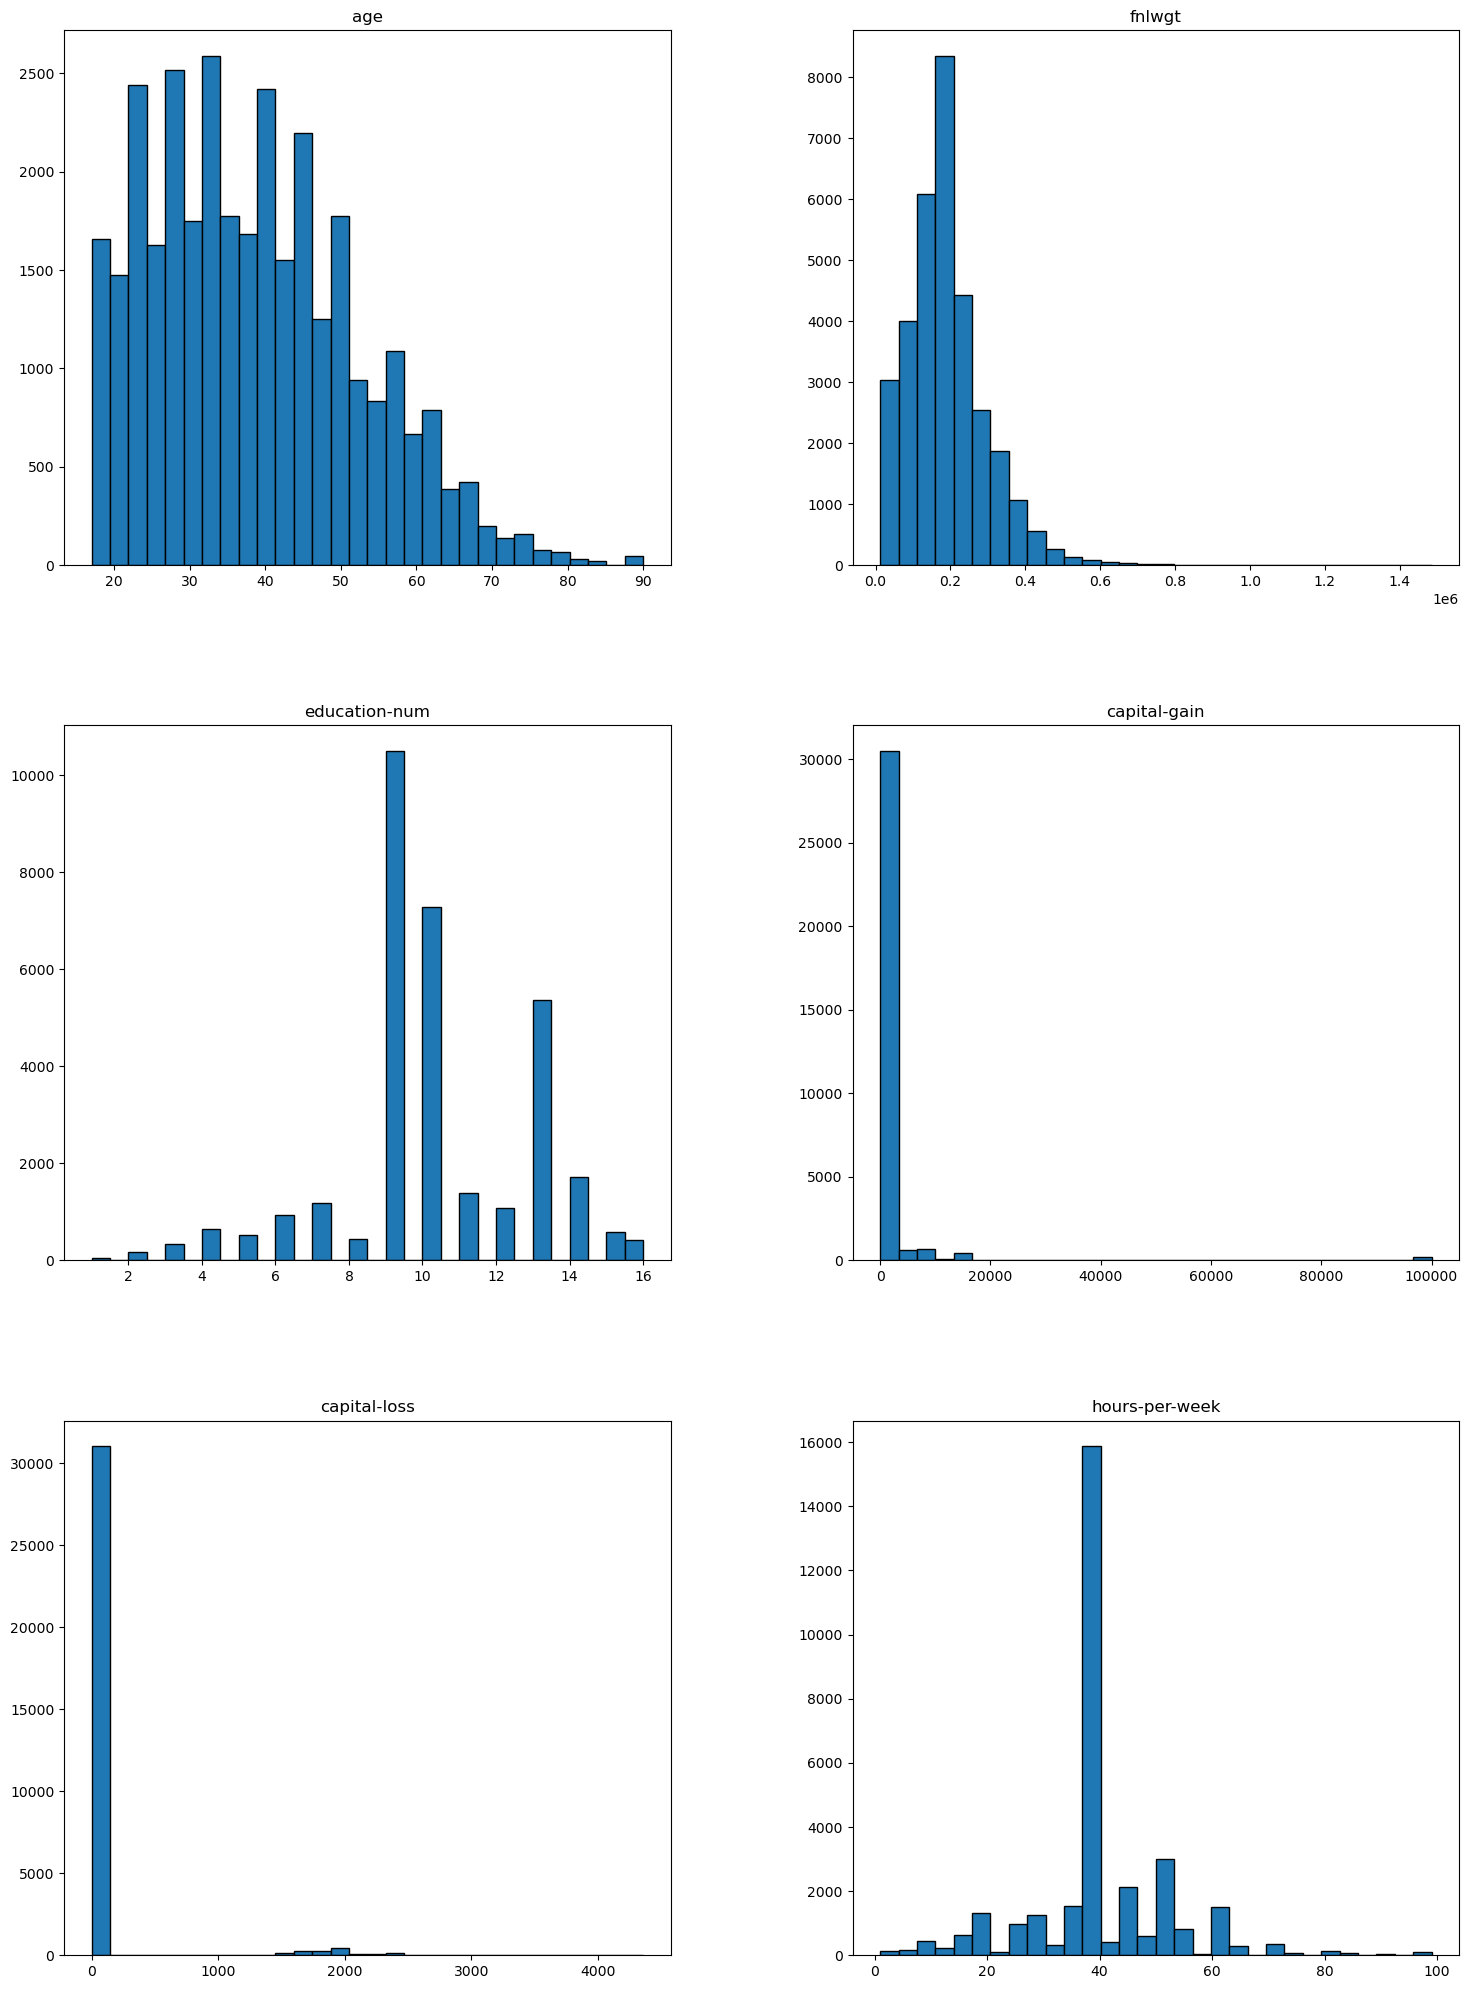

In [24]:
#data.shape
data.hist(bins=30, figsize=(18, 25),edgecolor='black', grid=False)
plt.show()

## Eliminación de los valores faltantes y ajuste del dataset 
En el dataset se ha observado la existencia de valores faltantes. Se observa que estos se encuentran en atributos que toman valores no numéricos lo cual será aprovechado para facilitar la extracción de estos. Como son atributos que toman valores no numéricos no tiene sentido sustituirlos por la media o la mediana, así que me he decantado por aplicar la moda, el valor más frecuente.

In [26]:
#Con este bucle transformamos los ? en NaN que serán tratados ahora en test  
for columna in atributos:
    #observando me he dado cuenta que los ? etán en los valores de tipo objeto
    if test[columna].dtypes == 'O': 
        test[columna] = test[columna].str.strip().replace('?', np.nan)

In [27]:
#Con este bucle transformamos los ? en NaN que serán tratados ahora en test
for columna in atributos:
    if data[columna].dtypes == 'O': 
        #observando me he dado cuenta que los ? etán en los valores de tipo objeto
        data[columna] = data[columna].str.strip().replace('?', np.nan)

In [28]:
data.head(20)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


In [29]:
test.head(10)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
1,25,Private,226802.0,11th,7.0,Never-married,Machine-op-inspct,Own-child,Black,Male,0.0,0.0,40.0,United-States,<=50K.
2,38,Private,89814.0,HS-grad,9.0,Married-civ-spouse,Farming-fishing,Husband,White,Male,0.0,0.0,50.0,United-States,<=50K.
3,28,Local-gov,336951.0,Assoc-acdm,12.0,Married-civ-spouse,Protective-serv,Husband,White,Male,0.0,0.0,40.0,United-States,>50K.
4,44,Private,160323.0,Some-college,10.0,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688.0,0.0,40.0,United-States,>50K.
5,18,NaN,103497.0,Some-college,10.0,Never-married,NaN,Own-child,White,Female,0.0,0.0,30.0,United-States,<=50K.
6,34,Private,198693.0,10th,6.0,Never-married,Other-service,Not-in-family,White,Male,0.0,0.0,30.0,United-States,<=50K.
7,29,NaN,227026.0,HS-grad,9.0,Never-married,NaN,Unmarried,Black,Male,0.0,0.0,40.0,United-States,<=50K.
8,63,Self-emp-not-inc,104626.0,Prof-school,15.0,Married-civ-spouse,Prof-specialty,Husband,White,Male,3103.0,0.0,32.0,United-States,>50K.
9,24,Private,369667.0,Some-college,10.0,Never-married,Other-service,Unmarried,White,Female,0.0,0.0,40.0,United-States,<=50K.
10,55,Private,104996.0,7th-8th,4.0,Married-civ-spouse,Craft-repair,Husband,White,Male,0.0,0.0,10.0,United-States,<=50K.


In [30]:
print("---data---")
res1 = data.isnull().sum() # lo guardamos porque despues lo vamos a usar 
print(res1)
print("---test---")
res2 = test.isnull().sum() # lo guardamos porque despues lo vamos a usar 
print(test.isnull().sum())

---data---
age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
class                0
dtype: int64
---test---
age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
class               0
dtype: int64


Aunque no nos interesa eliminar las filas en las que aparecen valores faltantes porque se pierden muchos datos, lo vamos a hacer para comprobar que los pasos anteriores
se han hecho correctamente, para ello vamos a observar que al eliminar los valores faltantes se obtiene el mismo número de filas y columnas que indica la documentación del dataset.


In [32]:
data1 = data.copy() #lo copiamos para que no afecte al original
data1.dropna(axis=0, how='any', inplace=True)
data1

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [33]:
print(data1.isnull().sum())

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
class             0
dtype: int64


In [34]:
test1 = test.copy() #lo copiamos para que no afecte al original
test1.dropna(axis=0, how='any', inplace=True) # eliminar los valores faltantes por fila
test1

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
1,25,Private,226802.0,11th,7.0,Never-married,Machine-op-inspct,Own-child,Black,Male,0.0,0.0,40.0,United-States,<=50K.
2,38,Private,89814.0,HS-grad,9.0,Married-civ-spouse,Farming-fishing,Husband,White,Male,0.0,0.0,50.0,United-States,<=50K.
3,28,Local-gov,336951.0,Assoc-acdm,12.0,Married-civ-spouse,Protective-serv,Husband,White,Male,0.0,0.0,40.0,United-States,>50K.
4,44,Private,160323.0,Some-college,10.0,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688.0,0.0,40.0,United-States,>50K.
6,34,Private,198693.0,10th,6.0,Never-married,Other-service,Not-in-family,White,Male,0.0,0.0,30.0,United-States,<=50K.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16276,33,Private,245211.0,Bachelors,13.0,Never-married,Prof-specialty,Own-child,White,Male,0.0,0.0,40.0,United-States,<=50K.
16277,39,Private,215419.0,Bachelors,13.0,Divorced,Prof-specialty,Not-in-family,White,Female,0.0,0.0,36.0,United-States,<=50K.
16279,38,Private,374983.0,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Husband,White,Male,0.0,0.0,50.0,United-States,<=50K.
16280,44,Private,83891.0,Bachelors,13.0,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455.0,0.0,40.0,United-States,<=50K.


Como podemos ver al eliminar las filas de valores faltantes nos sale 30162 filas para el conjunto de entrenamiento y 15060 para el conjunto de prueba, estos valores coinciden con los que aparecen en la información del dataset (old.adult.names).

Definitivamente vamos a rellenar los valores faltantes con el valor más frecuente de la cada columna

In [37]:
#Eliminamos los valores faltantes de data mediante este bucle
# iteramos las el sumatorio de faltantes por columnas y la lista de nombres de los atributos
for (i,col) in zip(res1,atributos) :
    # si hay algún valor faltantes
    if i > 0 :
        # completamos con la moda
        data[col] = data[col].fillna(data[col].mode()[0])
# Hacemos lo mismo para los test
for (i,col) in zip(res2,atributos) :
    # si hay algún valor faltantes
    if i > 0 :
        # completamos con la moda
        test[col] = test[col].fillna(test[col].mode()[0])

In [38]:
print(data.isnull().sum())

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
class             0
dtype: int64


In [39]:
print(test.isnull().sum())

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
class             0
dtype: int64


A continuación se extraen los conjuntos que contienen los valores de clasificación de los conjuntos de entrenamientos. Estos conjuntos se transforman para trabajar con valores numéricos.

In [41]:
#Vamos a quedarnos con los datos del conjunto de entrenamiento
x_train = data.iloc[:,:-1]

In [42]:
#Vamos a quedarnos con los datos de valores de clasificación
y_train = data.iloc[:,-1]

In [43]:
# Observación en la tabla 
x_train.head(10)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States


In [44]:
y_train.head(10)

0    <=50K
1    <=50K
2    <=50K
3    <=50K
4    <=50K
5    <=50K
6    <=50K
7     >50K
8     >50K
9     >50K
Name: class, dtype: object

In [45]:
#Hacemos lo mismo para el conjunto de prueba 
x_test = test.iloc[:, :-1]
y_test = test.iloc[:,-1]

In [46]:
#Veamos como queda
x_test.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
1,25,Private,226802.0,11th,7.0,Never-married,Machine-op-inspct,Own-child,Black,Male,0.0,0.0,40.0,United-States
2,38,Private,89814.0,HS-grad,9.0,Married-civ-spouse,Farming-fishing,Husband,White,Male,0.0,0.0,50.0,United-States
3,28,Local-gov,336951.0,Assoc-acdm,12.0,Married-civ-spouse,Protective-serv,Husband,White,Male,0.0,0.0,40.0,United-States
4,44,Private,160323.0,Some-college,10.0,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688.0,0.0,40.0,United-States
5,18,Private,103497.0,Some-college,10.0,Never-married,Prof-specialty,Own-child,White,Female,0.0,0.0,30.0,United-States


In [47]:
#Veamos como queda
y_test.head(10)

1     <=50K.
2     <=50K.
3      >50K.
4      >50K.
5     <=50K.
6     <=50K.
7     <=50K.
8      >50K.
9     <=50K.
10    <=50K.
Name: class, dtype: object

In [48]:
#Hemos pasado los valores de clasificaión de valores no númerricos a valores entreso biniarios 
y_test = y_test.copy()
y_test.loc[y_test.str.strip() == '<=50K.'] = 0
y_test.loc[y_test.str.strip() == '>50K.'] = 1
y_test = y_test.astype(np.int32)

In [49]:
#Resultado del test
y_test.head(10)

1     0
2     0
3     1
4     1
5     0
6     0
7     0
8     1
9     0
10    0
Name: class, dtype: int32

In [50]:
#Hemos pasado los valores de clasificaión de valores no numéricos a valores biniarios
y_train = y_train.copy()
y_train[y_train.str.strip() == '<=50K'] = 0
y_train[y_train.str.strip() == '>50K'] = 1
y_train = y_train.astype(np.int32)

In [51]:
#Resultado del entrenamiento
y_train.head(10)

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    1
8    1
9    1
Name: class, dtype: int32

A continuación se va a proceder a la modificación del dataset para transformar los valores no numéricos en valores binarios en algunos atributos del conjunto del dataset en el que no es necesario aplicarle ONE-HOT encoding ya que tienen a lo sumo dos atributos.También se observa que las columnas education y education-num están relacionadas por lo que de cierta forma education "ya están escalados sus valores a valores numéricos" y nos podemos ahorrar esta columna.

In [53]:
#Vamos a transformar la columna sex del conjunto de entrenamiento 
x_train.loc[x_train['sex'].astype('str') == 'Male', 'sex'] = 0
x_train.loc[x_train['sex'].astype('str') == 'Female', 'sex'] = 1
x_train['sex'] = x_train['sex'].astype(np.int32)
#Eliminación de la columna de educación 
del x_train['education']
print("Tamaño del dataset: ",  x_train.shape)
print("Columnas del dataset: ",  x_train.columns)

Tamaño del dataset:  (32561, 13)
Columnas del dataset:  Index(['age', 'workclass', 'fnlwgt', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'sex', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country'],
      dtype='object')


In [54]:
x_train.head()

,age,workclass,fnlwgt,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,77516,13,Never-married,Adm-clerical,Not-in-family,White,0,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,13,Married-civ-spouse,Exec-managerial,Husband,White,0,0,0,13,United-States
2,38,Private,215646,9,Divorced,Handlers-cleaners,Not-in-family,White,0,0,0,40,United-States
3,53,Private,234721,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,0,0,0,40,United-States
4,28,Private,338409,13,Married-civ-spouse,Prof-specialty,Wife,Black,1,0,0,40,Cuba


In [55]:
#Vamos a transformar la columna sex del conjunto de entrenamiento 
x_test.loc[x_test['sex'].astype('str') == 'Male', 'sex'] = 0
x_test.loc[x_test['sex'].astype('str') == 'Female', 'sex'] = 1
x_test['sex'] = x_test['sex'].astype(np.int32)
#Eliminación de la columna de educación en el conjnuto de test 
del x_test['education']
print("Tamaño del dataset: {}".format( x_test.shape))
print("Columnas del dataset: {} ".format(x_test.columns))
print(x_test.isnull().sum())

Tamaño del dataset: (16281, 13)
Columnas del dataset: Index(['age', 'workclass', 'fnlwgt', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'sex', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country'],
      dtype='object') 
age               0
workclass         0
fnlwgt            0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
dtype: int64


In [56]:
x_test.head()

,age,workclass,fnlwgt,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
1,25,Private,226802.0,7.0,Never-married,Machine-op-inspct,Own-child,Black,0,0.0,0.0,40.0,United-States
2,38,Private,89814.0,9.0,Married-civ-spouse,Farming-fishing,Husband,White,0,0.0,0.0,50.0,United-States
3,28,Local-gov,336951.0,12.0,Married-civ-spouse,Protective-serv,Husband,White,0,0.0,0.0,40.0,United-States
4,44,Private,160323.0,10.0,Married-civ-spouse,Machine-op-inspct,Husband,Black,0,7688.0,0.0,40.0,United-States
5,18,Private,103497.0,10.0,Never-married,Prof-specialty,Own-child,White,1,0.0,0.0,30.0,United-States


## ONE-HOT ENCODING 
Aquí se aplicará one-hot encoding para tratar los atributos no numéricos que toman muchos valores y de esta forma convertirlos en atributos numéricos binarios.

In [58]:
#Vamos a añdir los atributos no numéricos a una lista para acceder a ellos 
cat_str = []
for cols in x_train.columns:
    if x_train[cols].dtype == 'O':
        cat_str.append(cols)
print(cat_str)

['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'native-country']


In [59]:
#Importamos el clasificador One Hot 
from sklearn.preprocessing import OneHotEncoder
# A continuación vamos a inicializar el OneHotEncoder indicando sparse_output=True 
# de esta manera vamos a obtener mayor eficiencia en memoria ya que solo va a guaradar los 1
# Nos viene bien porque se va a generar un datset muy denso 
#
encoder = OneHotEncoder(sparse_output=True,handle_unknown='ignore')
# Ajustamos en codificador y trasnformamos en conjunto de datos extrayendo solo los atributo no numéricos
encoder.fit(x_train[cat_str])
result_encd_train = encoder.transform(x_train[cat_str])

In [60]:
encoder.categories_

[array(['Federal-gov', 'Local-gov', 'Never-worked', 'Private',
        'Self-emp-inc', 'Self-emp-not-inc', 'State-gov', 'Without-pay'],
       dtype=object),
 array(['Divorced', 'Married-AF-spouse', 'Married-civ-spouse',
        'Married-spouse-absent', 'Never-married', 'Separated', 'Widowed'],
       dtype=object),
 array(['Adm-clerical', 'Armed-Forces', 'Craft-repair', 'Exec-managerial',
        'Farming-fishing', 'Handlers-cleaners', 'Machine-op-inspct',
        'Other-service', 'Priv-house-serv', 'Prof-specialty',
        'Protective-serv', 'Sales', 'Tech-support', 'Transport-moving'],
       dtype=object),
 array(['Husband', 'Not-in-family', 'Other-relative', 'Own-child',
        'Unmarried', 'Wife'], dtype=object),
 array(['Amer-Indian-Eskimo', 'Asian-Pac-Islander', 'Black', 'Other',
        'White'], dtype=object),
 array(['Cambodia', 'Canada', 'China', 'Columbia', 'Cuba',
        'Dominican-Republic', 'Ecuador', 'El-Salvador', 'England',
        'France', 'Germany', 'Greece', '

In [61]:
result_encd_train.toarray().shape

(32561, 81)

In [62]:
atrib_train = encoder.get_feature_names_out()
#te devuelve los distintos valores de clasificación 

In [63]:
#Eliminamos del conjnuto de entrenamiento las columnas originales que hemos transformado
x_train.drop(columns = cat_str)

,age,fnlwgt,education-num,sex,capital-gain,capital-loss,hours-per-week
0,39,77516,13,0,2174,0,40
1,50,83311,13,0,0,0,13
2,38,215646,9,0,0,0,40
3,53,234721,7,0,0,0,40
4,28,338409,13,1,0,0,40
...,...,...,...,...,...,...,...
32556,27,257302,12,1,0,0,38
32557,40,154374,9,0,0,0,40
32558,58,151910,9,1,0,0,40
32559,22,201490,9,0,0,0,20


In [64]:
x_enc_train = pd.DataFrame(result_encd_train.toarray(), columns = atrib_train) # creamos un nuevo dataframe con array que devuelve onehot 
x_enc_train.head()

,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,marital-status_Divorced,marital-status_Married-AF-spouse,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [65]:
x_train_t =  pd.concat([x_train.drop(columns = cat_str),x_enc_train], axis=1) # solapamos dataframe original con el nuevo resultante 
x_train_t.head()

,age,fnlwgt,education-num,sex,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,39,77516,13,0,2174,0,40,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,50,83311,13,0,0,0,13,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,38,215646,9,0,0,0,40,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,53,234721,7,0,0,0,40,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,28,338409,13,1,0,0,40,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [66]:
# Hacems lo mismo para el test 
# Para evitar problemas aplicamos el mismo encoder al test 
result_encd_test = encoder.transform(x_test[cat_str])
atrib_test = encoder.get_feature_names_out()
x_enc_test = pd.DataFrame(result_encd_test.toarray(), columns = atrib_test)
x_enc_test.head()
#Para que no de problemas con el orden de los indices los reseteamos  
x_test_t =  pd.concat([x_test.drop(columns = cat_str).reset_index(drop=True),x_enc_test.reset_index(drop=True)], axis=1)
x_test_t.head()

,age,fnlwgt,education-num,sex,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,25,226802.0,7.0,0,0.0,0.0,40.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,38,89814.0,9.0,0,0.0,0.0,50.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,28,336951.0,12.0,0,0.0,0.0,40.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,44,160323.0,10.0,0,7688.0,0.0,40.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,18,103497.0,10.0,1,0.0,0.0,30.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## Escalado de datos 
Como posteriormente vamos aplicar el modelo de clasificación de regresión logística, sería una buena idea escalar los datos, para ello se va a emplear el método de estandarización.

In [68]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(x_train_t)
# guaradamos el nombre de las categorías para trabajar con ellas 
nombr_cat = scaler.feature_names_in_ #guardamos el nombre de las columnas
res_train_s = scaler.transform(x_train_t)
res_test_s = scaler.transform(x_test_t) # Aplicamos el mismo escalado al conjunto de test 
x_train_s = pd.DataFrame(res_train_s, columns = nombr_cat) # construimos del dataframe con los array de numpy resultantes 
x_test_s = pd.DataFrame(res_test_s, columns = nombr_cat) # construimos del dataframe con los array de numpy resultantes

## Aplicación de PCA 

Se intentará reducir la dimensionalidad del dataset mediante el uso de PCA y conseguir así una mejora en las predicciones.  

In [70]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95) # Se indica que se quiere el 95 % de la varianza 
pca.fit(x_train_s) # Ajuste 
x_train_pca = pca.transform(x_train_s) # Se trasnforma el conjnto de entrenamiento
print("Dimensiones originales: {}".format(str(x_train_s.shape))) 
print("Dimensiones reducidas con PCA: {}".format(str(x_train_pca.shape)))
print("Componentes PCA:  {}".format(pca.components_))

Dimensiones originales: (32561, 88)
Dimensiones reducidas con PCA: (32561, 73)
Componentes PCA:  [[ 2.31221128e-01 -3.51495493e-02  9.35283249e-02 ...  3.73996144e-02
  -1.61241548e-02  6.78870942e-03]
 [ 8.09377448e-03  5.92657399e-02 -1.21065026e-01 ... -4.84447102e-01
   1.37057839e-01  2.04699923e-02]
 [ 2.96615907e-01 -6.38591418e-02  2.13499743e-01 ...  2.03986883e-02
   1.49067852e-02 -1.11635077e-02]
 ...
 [-3.97706680e-03  1.91715101e-01  2.72827532e-02 ... -8.25034794e-02
   4.19619494e-02 -5.47205602e-02]
 [ 6.79793035e-02  3.13316463e-01  1.69122881e-02 ... -1.20550080e-02
   4.68610704e-04 -3.90524146e-02]
 [ 1.35176692e-01  7.55334431e-02  2.62087314e-02 ...  4.51508891e-02
  -1.13201248e-02  6.19457480e-03]]


Nube de puntos de las 2 primeras PCA: 
- En el eje X se observa cómo se mueve la varianza de la primera componente principal.
- En el eje Y se observa cómo se mueve la varianza de la segunda componente principal.

Los puntos se colorean en función de la clasificación:
- El amarillo clasifica a lo que ganan más de 50k de salario bruto
- El morado clasifica a lo que ganan menos o igual 50k de salario bruto

A la izquierda se encuentra una leyenda (código de colores).


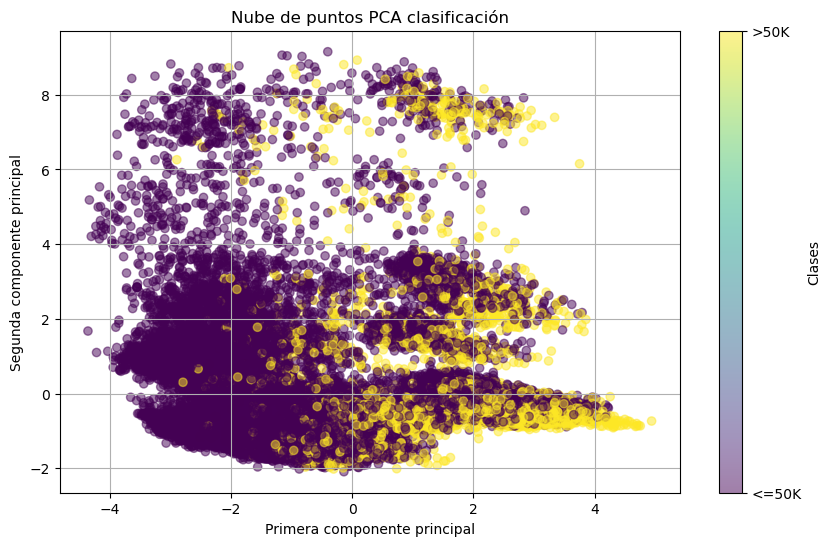

In [72]:
plt.figure(figsize=(10, 6))
# definimos los ejes x, y,con alpha = 0.5 hacemos los puntos un poco transparentes para que se vean bien
# c=y_train estamos el parametroq que clasifica y con cmap='viridis' mapeamos esos valores de clasificación con colores
scatter = plt.scatter(x_train_pca[:, 0], x_train_pca[:, 1], alpha=0.5, c=y_train, cmap='viridis')
#Creación de la leyenda/código de colores
cbar = plt.colorbar(scatter, ticks=[0, 1])
cbar.set_label('Clases')
cbar.set_ticklabels(['<=50K', '>50K']) 
#Las etiquetas de la función 
plt.xlabel("Primera componente principal")
plt.ylabel("Segunda componente principal")
plt.title("Nube de puntos PCA clasificación")
# le añadimos una cuadrícula
plt.grid()
plt.show()

Podemos observar el comportamiento de la varianza acumulada através de una gráfica 

Text(0, 0.5, 'Varianza acumulada')

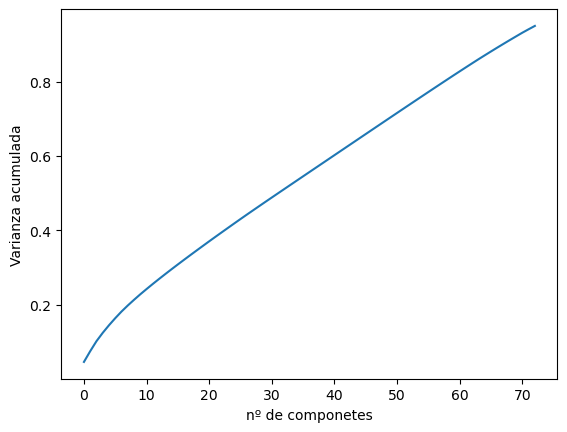

In [74]:
plt.plot(np.cumsum(pca.explained_variance_ratio_)) #con np.cumsum calculamos a la suma acumulada de la varianzza explicada
plt.xlabel('nº de componetes')
plt.ylabel('Varianza acumulada')

In [75]:
#Aplicamos PCA al conjunto de test, aplicamos la mimas PCA del conjunto de entrenamiento al conjunto de test 
x_test_pca = pca.transform(x_test_s)
print("Dimensiones originales: {}".format(str(x_test_s.shape)))
print("Dimensiones reducidas con PCA: {}".format(str(x_test_pca.shape)))

Dimensiones originales: (16281, 88)
Dimensiones reducidas con PCA: (16281, 73)


# Segunda Parte : Aplicación de modelos 
En esta segunda parte se van a aplicar modelos de clasificación, añadiendo una conclusión de los resultados y se van a guardar sus resultados para evaluarlos posteriormente, los modelos apliacados serán:

    - SVC.
    - Regresión Logística.
    - Arboles de decisión
    - Knn


## Ajuste de hiper parámetros 

Vamos ajustar los hiperparametros para aplicarlo a svc, posteriormente lo volveremos a aplicar para otros modelos. Para el ajuste se ha elegido la técnica GridSearchCV ya que prueba todas las combinaciones de parámetros y no está sujeto a aleatoriedad.


In [78]:
#Tarda un poco
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
model = SVC()
params = {
    'C': [0.1, 1, 10],  # Valores reducidos
    'gamma': [0.1, 0.01, 0.001]  # Valores reducidos
}
#Ajustamos GridSearchCV
# cv indica que se realizará validación cruzada con 5 particiones, se pone esta para que tarde menos  
# la métrica que se usuara es la tasa de acierto
gscv = GridSearchCV(model, params, cv=5, scoring='accuracy')
# x_train_pca[:1000] se toma una parte del conjunto de entrenamiento porque sino tardaría mucho 
gscv.fit(x_train_pca[:1000],y_train[:1000])
# Almacenamos los mejores parametros que nos da
c_best = gscv.best_params_['C']
gamma_best = gscv.best_params_['gamma']
print("Mejor valor para el parametro C: {} ".format(c_best))
print("Mejor valor para el parametro gamma: {} ".format(gamma_best))

Mejor valor para el parametro C: 10 
Mejor valor para el parametro gamma: 0.001 


In [79]:
predicciones = {} 

### SVC
El primer modelo de clasificación que se va a aplicar es SVC .
Con los hiper parámetros calculados anteriormente vamos a inicializar la máquina de vectores soporte 
y luego vamos a medir su rendimiento.


In [81]:
# Tarda un poco 
from sklearn.metrics import accuracy_score
#LLamammos al modelo y le asignamos los parametros resultantes de grid Search
svc = SVC(C=c_best, gamma = gamma_best)
svc.fit(x_train_pca,y_train)
print(svc.score(x_train_pca,y_train)) # mostramos el rendimiento sobre el conjunto de entrenamiento 

0.8545806332729339


In [82]:
print(svc.score(x_test_pca,y_test)) # mostramos el rendimiento sobre el conjunto de evaluación

0.8514219028315214


In [83]:
# Aquí se guarda los resultados de predicciones que serán utilizados posteriormente
y_pred_svc=svc.predict(x_test_pca)
predicciones['svc'] = y_pred_svc

In [84]:
print("Redimiento obtenido: {}".format(accuracy_score(y_test, y_pred_svc))) # esta métrica de rendimiento, tasa de acierto es la que 
# usan los modelos en general, la he puesto para mostra cual es la métrica que utilizan los modelos 

Redimiento obtenido: 0.8514219028315214


**Resultado:**  Obtenemos un buen rendimiento que supera el 80% en el accuracy_score, tasa de acierto, además podemos observar que apenas hay sobreajuste.

### Regresión logística
El siguiente modelo que se va a aplicar es Regresión logística

In [87]:
from sklearn.linear_model import LogisticRegression 
from matplotlib.colors import ListedColormap 
rloc = LogisticRegression()
rloc.fit(x_train_pca, y_train)
print('Exactitud del conjunto del de entrenamiento: {}'.format(rloc.score(x_train_pca, y_train)))
print('Exactitud del conjunto de prueba: {}'.format(rloc.score(x_test_pca, y_test)))
y_pred_rloc = rloc.predict(x_test_pca)
predicciones['reglog'] = y_pred_rloc

Exactitud del conjunto del de entrenamiento: 0.8507109732502073
Exactitud del conjunto de prueba: 0.8495792641729624


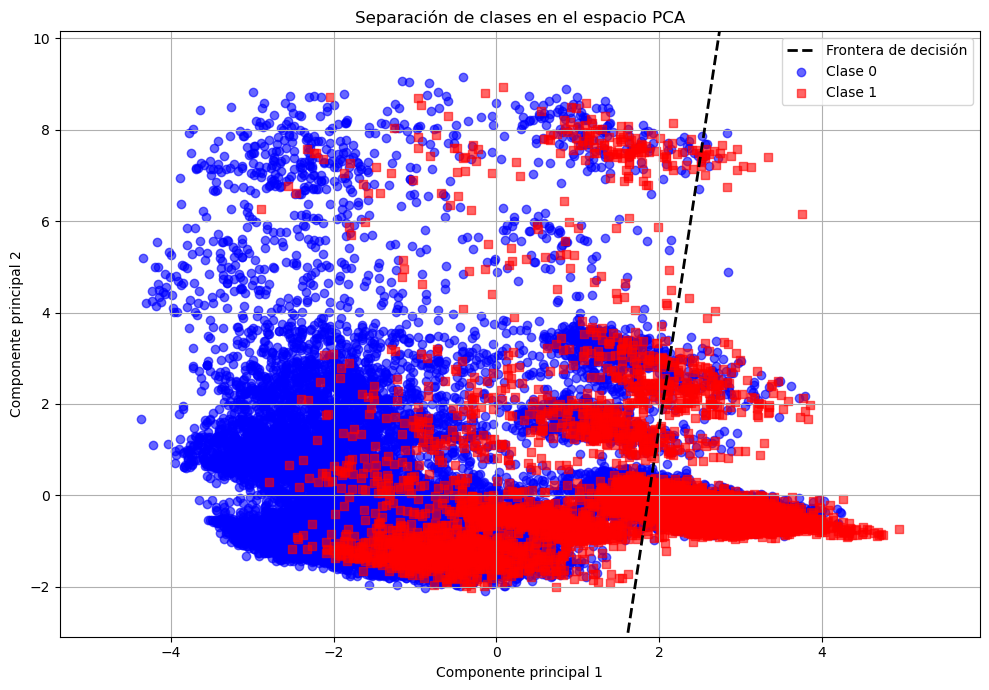

In [88]:
plt.figure(figsize=(10, 7))

# Creación  malla de puntos para la línea de decisión
x_min, x_max = x_train_pca[:, 0].min() - 1, x_train_pca[:, 0].max() + 1
y_min, y_max = x_train_pca[:, 1].min() - 1, x_train_pca[:, 1].max() + 1
xx = np.linspace(x_min, x_max, 200)

# Cálculo de la frontera de decisión
coef = rloc.coef_[0] #aquí se almacenan los pesos pque el modelo aprende
intercept = rloc.intercept_[0] # aquí se almaceno el peso w0 (bias)
yy = -(coef[0] * xx + intercept) / coef[1]

# Representación de la frontera de decisión
plt.plot(xx, yy, 'k--', label='Frontera de decisión', linewidth=2)

# Graficar puntos por clase
# En azul la clase 0 y en rojo a la 1 
colors = ['blue', 'red']
# circulos para la calse 0 y cuadrados para la 1
markers = ['o', 's']
for clase in range(2):
    indices = np.where(y_train == clase)
    plt.scatter(x_train_pca[indices, 0], x_train_pca[indices, 1],
                c=colors[clase], marker=markers[clase], alpha=0.6,
                label=f'Clase {clase}')

# Etiquetas
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.title("Separación de clases en el espacio PCA")
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)  
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

**Resultados:**  Aquí se obtienen unos resultados parecidos a los resultados anteriores obtenidos con SVC en cuanto a tasa de acierto, sin embargo aquí sí se ha tenido un poquito más de sobre ajuste.

### Arboles de decisión

El tercer modelo que vamos a aplicar es el de Random Forest  
Se va a proceder al ajuste de hiperparametros, aunque también se va a hacer una predicción sin este ajuste para observar cuanto mejora esta técnica a la predicción.

In [93]:
from sklearn.ensemble import RandomForestClassifier
#Con random_state le ponemos la semilla a 42, de esta forma nos aseguramos que siempre va a dar el mismo reusltado 
# si los pasos se ejecutan en orden.
model = RandomForestClassifier(random_state = 42)
# Vamos a ajustar el mínimo número de muestras divididas, la maxima profundidad y el número de arboles para el modelo
params = {
    'n_estimators': [10, 15, 30],      
    'max_depth': [3, 5, 7],          
    'min_samples_split': [2, 3, 4]     
}
#Ajuste de hiper parametros mediante grid search
gscv2 = GridSearchCV(model, params, cv=5, scoring='accuracy')
gscv2.fit(x_train_pca[:1000],y_train[:1000])
#guardamos los valores que nos da grid search
n_estimators_best = gscv2.best_params_['n_estimators']
max_depth_best = gscv2.best_params_['max_depth']
min_samples_split_best = gscv2.best_params_['min_samples_split']
print("Mejor valor para el parametro n_estimators: {} ".format(n_estimators_best))
print("Mejor valor para el parametro max_depth: {} ".format(max_depth_best))
print("Mejor valor para el parametro min_samples_split: {} ".format(min_samples_split_best))

Mejor valor para el parametro n_estimators: 30 
Mejor valor para el parametro max_depth: 7 
Mejor valor para el parametro min_samples_split: 3 


In [94]:
from sklearn.ensemble import RandomForestClassifier
#modelo con los parametros aleatorios sin ajustar
#Aplicamos random Forest con los parametros resultantes de grid search
forest = RandomForestClassifier(random_state = 42 , min_samples_split = min_samples_split_best, max_depth = max_depth_best , n_jobs=-1, criterion = 'gini', n_estimators=n_estimators_best)
# Entrenamiento del modelo 
forest.fit(x_train_pca, y_train)
print("Exactitud de conjunto de entrenamiento {}".format(forest.score(x_train_pca, y_train)))
print("Exactitud de conjunto de test {}".format(forest.score(x_test_pca, y_test)))
# Aquí se guarda los resultados de predicciones que serán utilizados posteriormente
y_pred_forest = forest.predict(x_test_pca)
predicciones['rdFores'] = y_pred_forest

Exactitud de conjunto de entrenamiento 0.839501243819293
Exactitud de conjunto de test 0.8313985627418463


Aplicación de Random Forest sin haber aplicado previamente ajuste de hiperparametros 

In [96]:
# Para ver como sería sin el ajuste de hyperparametros.
forest2 = RandomForestClassifier(random_state = 42, max_depth = 3 , n_jobs=-1, criterion = 'gini', n_estimators=15)
forest2.fit(x_train_pca, y_train)
print("Exactitud de conjunto de entrenamiento {}".format(forest2.score(x_train_pca, y_train)))
print("Exactitud de conjunto de test {}".format(forest2.score(x_test_pca, y_test)))

Exactitud de conjunto de entrenamiento 0.7946930376831178
Exactitud de conjunto de test 0.7960199004975125


**Resultados:**   Con random Forest sin el ajuste de hiper parámetros se ha obtenido peor resultado que con el ajuste. Es verdad que se observa un leve empeoramiento con respecto a los resultados de los 2 modelos anteriores.


### KNN
El ultimo de modelo que se va a usar es KNN.
En primer lugar se realizara ajuste de hiperparametros y luego se apliacará el modelo.
Por ultimo probaremos como sería este modelo sin ajuste de hyper parametros 

In [99]:
from sklearn.neighbors import KNeighborsClassifier 
model = KNeighborsClassifier()
# Ajustemos los hiperparametros
params = {
    'n_neighbors': [3,5, 10, 15, 20],  # núemros de vecinos = k 
    'metric': ['euclidean', 'manhattan', 'cosine'],  # Distancia
    'weights': ['uniform', 'distance'] # Para darle más peso a lo más cercanos o no 
} 
gscv3 = GridSearchCV(model, params, cv=5, scoring='accuracy')
gscv3.fit(x_train_pca[:1000],y_train[:1000])
n_neighbors_best = gscv3.best_params_['n_neighbors']
metric_best = gscv3.best_params_['metric']
weights_best = gscv3.best_params_['weights']
print("Mejor valor para el parametro n_neighbors_best: {} ".format(n_neighbors_best))
print("Mejor valor para el parametro metric_best: {} ".format(metric_best))
print("Mejor valor para el parametro weights_best: {} ".format(weights_best))
#Ajustar el modelo y entrenarlo 
knn = KNeighborsClassifier(n_neighbors = n_neighbors_best, metric = metric_best, weights = weights_best)
knn.fit(x_train_pca,y_train)
print("Exactitud de conjunto de entrenamiento {}".format(knn.score(x_train_pca, y_train)))
print("Exactitud de conjunto de entrenamiento {}".format(knn.score(x_test_pca, y_test)))
# Vamos a probar con otros parametros distintos a lo que me ha dado el ajuste de hyper parametro
knn2 = KNeighborsClassifier(n_neighbors = 20, metric = metric_best, weights = 'distance')
knn2.fit(x_train_pca,y_train)
print("Probando con otros parametros distinto a los que me ha dado el ajuste de hyper parametros")
print("Exactitud de conjunto de entrenamiento {}".format(knn2.score(x_train_pca, y_train)))
print("Exactitud de conjunto de entrenamiento {}".format(knn2.score(x_test_pca, y_test)))
# Aquí se guarda los resultados de predicciones que serán utilizados posteriormente
y_pred_knn = knn.predict(x_test_pca)
predicciones['knn'] = y_pred_knn

Mejor valor para el parametro n_neighbors_best: 15 
Mejor valor para el parametro metric_best: euclidean 
Mejor valor para el parametro weights_best: uniform 
Exactitud de conjunto de entrenamiento 0.8539049783483308
Exactitud de conjunto de entrenamiento 0.8384620109329893
Probando con otros parametros distinto a los que me ha dado el ajuste de hyper parametros
Exactitud de conjunto de entrenamiento 0.9999692884125181
Exactitud de conjunto de entrenamiento 0.838523432221608


**Resultados:**  Mediante KNN con ajuste de hiperparametros se observa que la tasa de acierto para el conjunto de entrenamiento no difiere mucho de los resultados obtenidos hasta ahora, en cuanto al test si que se observa que hay un poquito de sobre ajuste. Si se observan los resultados de KNN con parámetros aleatorios, se puede apreciar que para el conjunto de entrenamiento ha obtenido una alta tasa de aciertos, pero el sobre ajuste que tiene el test es muy grande.

# Parte 3 : Métricas de Evaluación
En esta última parte del trabajo se van a implemnetar métricas para evaluar los resultados de los métodos aplicados anteriormente y poder comparar resultados para poder generar conclusiones.

## Curvas ROC 
Las curvas características operativas son curvas que se utilizan para comparar diferentes clasificadores a partir de los puntajes de su predicción.
En el eje de abscisas se encuentran la tasa de verdaderos positivos (TPR) también conocida como especificidad y en el eje de ordenadas se encuentran las tasas de falsos positivos (FPR) también conocidas como sensibilidad.En la función se representa una recta que sirve como umbral (aleatorio de area 0'5), todas las curvas por debajo de ese umbral tienen un peor desempeño y todas las que estén por encima tienen mejor desempeño.

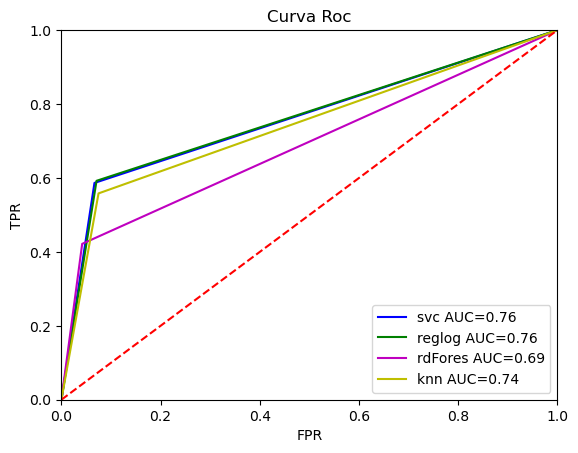

In [103]:
from sklearn.metrics import roc_curve, auc 
lc = ['b','g','m','y'] # lista de colores
for prd,c in zip(predicciones.keys(), lc):
    fpr,tpr,thresholds = roc_curve(y_test,predicciones[prd])  # se saca el fpr, tpr y umbrales de cada modelo 
    roc_auc = auc(fpr,tpr) # Cálculo del area bajo la curva de la recta 
    plt.plot(fpr,tpr,c,label= str(prd)+' AUC=%0.2f'%roc_auc) # dibjujar la recta y los parametros 
#representar la gráfica
plt.plot([0,1],[0,1],'r--') 
plt.xlim([0,1])
plt.ylim([0,1])
plt.ylabel('TPR')
plt.xlabel('FPR')
plt.title('Curva Roc')
plt.legend(loc='lower right')
plt.show()

### Explicación de la gráfica 
En las Curvas ROC todas las rectas tienen una curva que a medida que se vayan acercando a la izquierda y se situen lo más arriba posibe mejor se considera el modelo ya que supone un TPR cercano a 1 y un FPR cercano a 0.
En está gráfica todos los modelos están por encima del umbral, por lo que se pueden considerar aceptables.
Los modelos que están más arriba a la izquierda son SVC y regresión logística además son los que más AUC(area bajo la curva) tienen y por lo tanto son los mejores. Tras estos dos se encuentra un poco más desplazado KNN que tiene 0.74 de AUC y por ultimo está Randon Forest que es el peor de los 4 ya que tiene un AUC más bajo y tiene un TPR más bajo por lo que su curva se encuentra desplazada hacia abajo.   

## Resumen de las métricas y matriz de confunsión 
En sklearn existe una función **classification_report()** que devuelve un resumen de las metricas precisión, recall y F1

In [106]:
from sklearn import metrics 
# Vamos a mostrar las métricas de cada uno de los moedelos cuyas predicciones está guardadas en un diccionario
for prd in predicciones.keys():
    print("Resumen de las métricas de " + prd + " : ")
    print(metrics.classification_report(y_true=y_test, y_pred = predicciones[prd]))

Resumen de las métricas de svc : 
              precision    recall  f1-score   support

           0       0.88      0.93      0.91     12435
           1       0.73      0.59      0.65      3846

    accuracy                           0.85     16281
   macro avg       0.81      0.76      0.78     16281
weighted avg       0.84      0.85      0.85     16281

Resumen de las métricas de reglog : 
              precision    recall  f1-score   support

           0       0.88      0.93      0.90     12435
           1       0.72      0.59      0.65      3846

    accuracy                           0.85     16281
   macro avg       0.80      0.76      0.78     16281
weighted avg       0.84      0.85      0.84     16281

Resumen de las métricas de rdFores : 
              precision    recall  f1-score   support

           0       0.84      0.96      0.90     12435
           1       0.76      0.42      0.54      3846

    accuracy                           0.83     16281
   macro avg       

**Conclusiones:**  Casi todos los modelos tienen una precisión alta (pocos falsos positivos) y un recall alto (pocos falsos negativos) a la hora de predecir la clase 0. En cuanto a la clase 1 aquí hay una precisión aceptable que supera 0.70 pero no llega al 0.80 y tiene un recall más bajo (0.42-0.59). Los modelos con mejores resultados en macro avg (hace la media de las métricas) y weighted avg (hace la media de las métricas ponderando por el tamaño de las clases ) son regresión logística y SVC.
Podemos determinar que todos los modelos fallan más a la hora de predecir la clase 1 (clase minoritaria support = 3846), esto puede ser por problemas de clases desbalanceadas.


In [108]:
# Código para ma matriz de confunsión 
for prd in predicciones.keys():
    print("Matriz de confusión de " + prd + " : ")
    print(metrics.confusion_matrix(y_true=y_test, y_pred = predicciones[prd], labels = [0,1]))

Matriz de confusión de svc : 
[[11606   829]
 [ 1590  2256]]
Matriz de confusión de reglog : 
[[11554   881]
 [ 1568  2278]]
Matriz de confusión de rdFores : 
[[11914   521]
 [ 2224  1622]]
Matriz de confusión de knn : 
[[11504   931]
 [ 1699  2147]]


En esta matriz la clase negativa es la 0 y la positiva es la 1
En esta matriz la clase negativa es la 0 y la positiva es la 1 Los resultados arrojados muestran que el modelo que más True Positive tiene es regresión logística con 2278TP( rue Tositive)P, el que más aciertos tiene es SVC con 11606 T (True Negative)N + 2256 TP y el que más fallos tiene es Randon Forest con 521 F (False Negative)N y 2224 F (False Positive)P



### Curva de aprendizaje
Las curva de aprendizaje es una herramienta útil que muestra el rendimiento del aprendizaje de un modelo a medida que se incrementan las muestras del conjunto de entrenamiento. A continuación se va a crear una para el modelo que peores resultados ha tenido, Random Forest, para que sirva de ejemplo de cómo es una curva de aprendizaje.

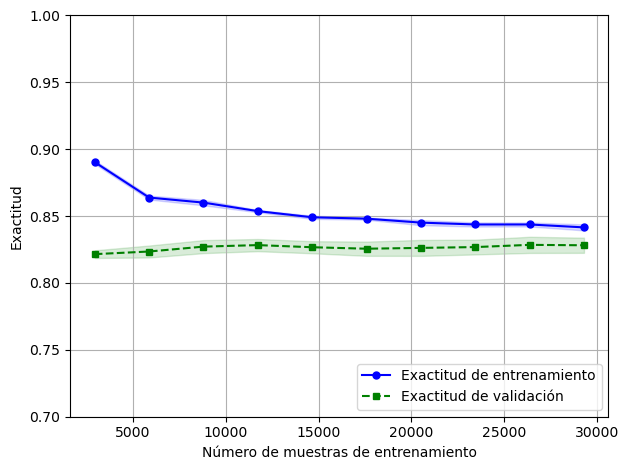

In [111]:
# Tarda un poco
from sklearn.model_selection import learning_curve
train_size, train_scores,test_scores = learning_curve(estimator=forest, X = x_train_pca, y = y_train , train_sizes = np.linspace(0.1, 1.0, 10), cv=10)
train_mean = np.mean(train_scores, axis=1) # Calcula la media de las puntuaciones del entrenamiento por tamaño 
train_std = np.std(train_scores, axis=1) # Calcula la desviación estandar  de las puntuaciones del entrenamiento por tamaño
test_mean = np.mean(test_scores, axis=1) # Calcula la media de las puntuaciones de la valicación por tamaño
test_std = np.std(test_scores, axis=1) # Calcula la desviación estandar  de las puntuaciones de la validación 
# muestra en una recta como varia en media el entranamiento 
plt.plot(train_size, train_mean, color = 'blue', marker = 'o', markersize = '5', label = 'Exactitud de entrenamiento')
# muestra la variabilidad de la función de forma un poco más trasnparente 
plt.fill_between(train_size, train_mean + train_std, train_mean - train_std, alpha = 0.15, color = 'blue')
# muestra en una recta como varia en media la validación
plt.plot(train_size, test_mean, color = 'green', linestyle = '--',marker = 's', markersize = '5', label = 'Exactitud de validación')
# muestra la variabilidad de la función de forma un poco más trasnparente
plt.fill_between(train_size, test_mean + test_std, test_mean - test_std, alpha = 0.15, color = 'green')
# Ajustes  de la gráfica 
plt.grid()
plt.xlabel('Número de muestras de entrenamiento')
plt.ylabel('Exactitud')
plt.legend(loc = 'lower right')
plt.ylim([0.7, 1.0])
plt.tight_layout()
plt.show()

La curva refleja que cuando hay menos muestras el sobre ajuste que hay es mucho mayor y a medida que aumenta el número de muestras el modelo memoriza menos y hay menor overfitting.
A medida que aumenta el número de muestras el rendimiento del entrenamiento disminuye y el rendimiento del test aumenta levemente


#### Bibliografía
Para este trabajo se ha usado la ayuda de :
- La librería oficial de sklearn https://scikit-learn.org/stable/
- Prácticas realizadas en clase
- El libro de Aprendizaje automático y profundo en Python, Una mirada hacia la inteligencia artificial, de Carlos M. Pineda Pertuz 


In [ ]:
# La mayoría de explicaciones se han puesto en formato Markdown, aunque hay algunos comentarios